# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectf** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 2** 

### **Feature engineering**

#### **Importation des Modules**

In [38]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


In [39]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [40]:
df = pd.read_csv("../data/processed/buildings_clean.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Importation du dataset terminée.
Dimensions du dataset : 1542 lignes, 34 colonnes


#### **Exploration du jeu de données**

Avant de créer de nouvelles variables, il est important de vérifier la structure du jeu de données importé.

Cette première inspection permet de :
- vérifier les dimensions du dataset ;
- identifier les variables disponibles ;
- contrôler les types de données ;
- préparer les prochaines étapes du feature engineering.

In [41]:
# Aperçu général du dataset

display(df.head())

print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

,osebuildingid,datayear,buildingtype,primarypropertytype,propertyname,address,city,state,zipcode,taxparcelidentificationnumber,...,secondlargestpropertyusetypegfa,thirdlargestpropertyusetype,thirdlargestpropertyusetypegfa,yearsenergystarcertified,siteenergyuse(kbtu),defaultdata,comments,compliancestatus,outlier,usage_type
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,NaN,NaN,NaN,NaN,7226362.5,False,NaN,Compliant,NaN,Mono-usage
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,15064.0,Restaurant,4622.0,NaN,8387933.0,False,NaN,Compliant,NaN,Multi-usages
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,NaN,NaN,NaN,NaN,72587024.0,False,NaN,Compliant,NaN,Mono-usage
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,NaN,NaN,NaN,NaN,6794584.0,False,NaN,Compliant,NaN,Mono-usage
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,68009.0,Swimming Pool,0.0,NaN,14172606.0,False,NaN,Compliant,NaN,Multi-usages


Nombre de lignes : 1542
Nombre de colonnes : 34


#### **Identification des variables disponibles**
identifier les différentes features disponibles dans le jeu de données.

In [42]:
# Liste des colonnes

pd.set_option("display.max_rows", None)

display(pd.DataFrame({
    "Feature": df.columns,
    "Type": df.dtypes.values
}))

,Feature,Type
0,osebuildingid,int64
1,datayear,int64
2,buildingtype,str
3,primarypropertytype,str
4,propertyname,str
5,address,str
6,city,str
7,state,str
8,zipcode,float64
9,taxparcelidentificationnumber,str


> - Les variables directement liées à la consommation énergétique ont été exclués afin d'éviter tout phénomène de **data leakage**.
> - Les nouvelles features seront principalement issues :
>  des caractéristiques structurelles du bâtiment ;
>  de son ancienneté ;
>  de son usage ;
>  de sa localisation.

## **Suppression des variables administratives**

> - Les variables administratives ne contribuent pas directement à la prédiction de la consommation énergétique et sont supprimées avant la phase de modélisation.

In [43]:
# Suppression des variables administratives

columns_to_remove = [
    "compliancestatus",
    "outlier",
    "yearsenergystarcertified"
]

df = df.drop(columns=columns_to_remove)

print(f"Dimensions du jeu de données : {df.shape}")


Dimensions du jeu de données : (1542, 31)


### **Feature Engineering - Création des Variables**

#### **Création de la variable BuildingAge** (Temporalité)


> - Transformation de l'année de construction en âge du bâtiment.
> - Cette variable permet de mieux représenter l'ancienneté du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [44]:
# Création de l'âge du bâtiment

df["BuildingAge"] = df["datayear"] - df["yearbuilt"]

# Vérification
df[["yearbuilt", "datayear", "BuildingAge"]].head()

,yearbuilt,datayear,BuildingAge
0,1927,2016,89
1,1996,2016,20
2,1969,2016,47
3,1926,2016,90
4,1980,2016,36



> - Cette nouvelle variable métier améliore l'interprétation de l'ancienneté des bâtiments et pourra être évaluée lors de l'analyse de corrélation afin de vérifier sa pertinence pour la modélisation.
> - L'âge est plus facilement interprétable que l'année de construction pour expliquer la consommation énergétique

#### **Création de la variable ParkingRatio** (Structure du bâtiment)

> - Calcul de la proportion de la surface dédiée au parking.
> - Cette variable décrit la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [45]:
# Création du ratio de surface de parking

df["ParkingRatio"] = (
    df["propertygfaparking"] / df["propertygfatotal"]
)

# Vérification
df[["propertygfaparking", "propertygfatotal", "ParkingRatio"]].head()

,propertygfaparking,propertygfatotal,ParkingRatio
0,0,88434,0.000000
1,15064,103566,0.145453
2,196718,956110,0.205748
3,0,61320,0.000000
4,62000,175580,0.353115


> - Cette nouvelle variable métier décrit la part de la surface consacrée au stationnement. Sa pertinence sera vérifiée lors de l'analyse de corrélation.

#### **Création de la variable BuildingRatio** (Structure du bâtiment)

> - Calcul de la proportion de la surface occupée par le bâtiment.
> - Cette variable complète la description de la structure du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [46]:
# Création du ratio de surface du bâtiment

df["BuildingRatio"] = (
    df["propertygfabuilding(s)"] / df["propertygfatotal"]
)

# Vérification
df[["propertygfabuilding(s)", "propertygfatotal", "BuildingRatio"]].head()

,propertygfabuilding(s),propertygfatotal,BuildingRatio
0,88434,88434,1.000000
1,88502,103566,0.854547
2,759392,956110,0.794252
3,61320,61320,1.000000
4,113580,175580,0.646885


> - Cette variable métier permet de représenter la proportion de surface effectivement construite. Sa pertinence sera évaluée lors de l'analyse de corrélation.

#### **Création de la variable IsMultiUse** (Structure / Usage du bâtiment)

> - Identification des bâtiments ayant plusieurs types d'usages.
> - Cette variable décrit la diversité des usages du bâtiment.
> - Elle est créée sans risque de **data leakage**.

In [47]:
# Création d'une variable binaire indiquant plusieurs usages

df["IsMultiUse"] = (
    df["listofallpropertyusetypes"]
    .str.contains(",", na=False)
    .astype(int)
)

# Vérification
df[["listofallpropertyusetypes", "IsMultiUse"]].head()

,listofallpropertyusetypes,IsMultiUse
0,Hotel,0
1,"Hotel, Parking, Restaurant",1
2,Hotel,0
3,Hotel,0
4,"Hotel, Parking, Swimming Pool",1


> - Cette variable métier simplifie l'information contenue dans les usages du bâtiment et permettra d'évaluer l'influence des bâtiments multi-usages sur la consommation énergétique.

#### **Création de la variable NumberPropertyUses** (Structure / Usage du bâtiment)

> - Comptage du nombre de types d'usages du bâtiment.
> - Cette variable complète l'information apportée par **IsMultiUse**.
> - Elle est créée sans risque de **data leakage**.
> - Cette variable reflète la complexité fonctionnelle du bâtiment.

In [48]:
# Comptage du nombre de types d'usages

df["NumberPropertyUses"] = (
    df["listofallpropertyusetypes"]
    .str.split(",")
    .str.len()
)

# Vérification
df[["listofallpropertyusetypes", "NumberPropertyUses"]].head()

,listofallpropertyusetypes,NumberPropertyUses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3


> - Cette nouvelle variable métier permet de quantifier la diversité des usages d'un bâtiment et pourra être évaluée lors de l'analyse de corrélation.

#### **Résumé des variables créées lors du Feature Engineering**

In [49]:
# Résumé des variables créées lors du Feature Engineering

feature_summary = pd.DataFrame({
    "Feature créée": [
        "BuildingAge",
        "ParkingRatio",
        "BuildingRatio",
        "IsMultiUse",
        "NumberPropertyUses"
    ],
    "Catégorie": [
        "Temporalité",
        "Structure du bâtiment",
        "Structure du bâtiment",
        "Structure / Usage du bâtiment",
        "Structure / Usage du bâtiment"
    ]
})

display(feature_summary)

,Feature créée,Catégorie
0,BuildingAge,Temporalité
1,ParkingRatio,Structure du bâtiment
2,BuildingRatio,Structure du bâtiment
3,IsMultiUse,Structure / Usage du bâtiment
4,NumberPropertyUses,Structure / Usage du bâtiment


### **Analyse de la variable cible**

> -  la distribution de la variable cible est analysée afin d'identifier une éventuelle asymétrie ou la présence de valeurs extrêmes.
> - Cette visualisation permet d'évaluer l'asymétrie de la distribution et de vérifier si une transformation de la variable cible pourra être envisagée lors de la phase de modélisation.

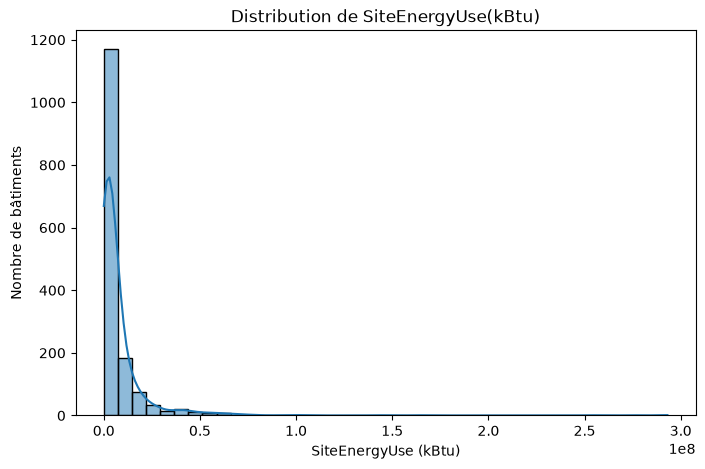

In [50]:
# Distribution de la variable cible

plt.figure(figsize=(8,5))

sns.histplot(
    df["siteenergyuse(kbtu)"],
    bins=40,
    kde=True
)

plt.title("Distribution de SiteEnergyUse(kBtu)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")

plt.show()

### **Analyse de la corrélation**

> -  Les valeurs extrêmes correspondent majoritairement à des bâtiments de grande taille et font partie de la variabilité naturelle du jeu de données. Elles sont donc conservées pour la modélisation.

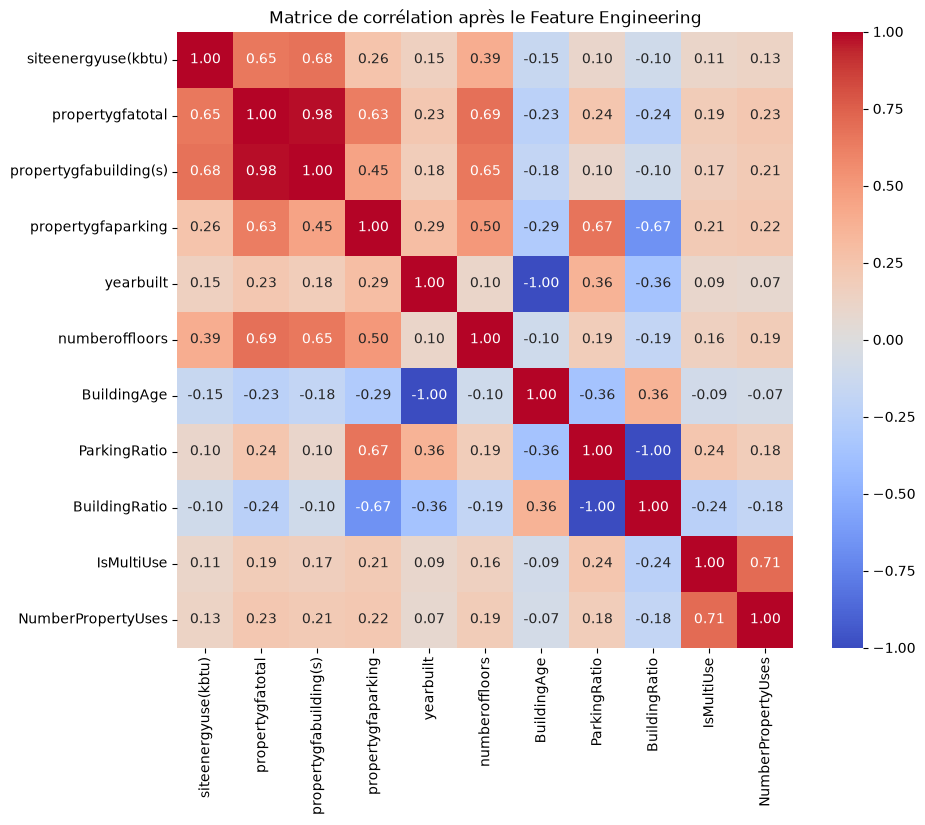

In [51]:
# Matrice de corrélation après le Feature Engineering

correlation_columns = [
    "siteenergyuse(kbtu)",
    "propertygfatotal",
    "propertygfabuilding(s)",
    "propertygfaparking",
    "yearbuilt",
    "numberoffloors",
    "BuildingAge",
    "ParkingRatio",
    "BuildingRatio",
    "IsMultiUse",
    "NumberPropertyUses"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Matrice de corrélation après le Feature Engineering")
plt.show()

> - Les variables **PropertyGFABuilding(s)** (0.68) et **PropertyGFATotal** (0.65) restent les plus fortement corrélées à la consommation énergétique.
> - Les nouvelles variables créées présentent des corrélations linéaires plus faibles avec la variable cible, mais elles apportent une information métier complémentaire susceptible d'améliorer les performances des modèles non linéaires.
> - La forte corrélation entre **IsMultiUse** et **NumberPropertyUses** (0.71) est cohérente, ces deux variables décrivant la diversité des usages d'un bâtiment.

### **Suppression des variables devenues redondantes**

> - La variable yearbuilt est supprimée, car son information est désormais représentée par BuildingAge, plus directement interprétable pour les modèles de prédiction.

In [52]:
# Suppression de la variable devenue redondante
df = df.drop(columns=["yearbuilt"])

print("'yearbuilt' supprimée.")

'yearbuilt' supprimée.


> - La variable `listofallpropertyusetypes` est supprimée après la création des variables `IsMultiUse` et `NumberPropertyUses`.

In [53]:
# Suppression de la variable devenue redondante
df = df.drop(columns=["listofallpropertyusetypes"])

print("'listofallpropertyusetypes' supprimée.")

'listofallpropertyusetypes' supprimée.


## **Conclusion**

> - Cinq nouvelles variables métier ont été créées afin d'enrichir le jeu de données.
> - Les variables peu pertinentes ainsi que celles susceptibles de provoquer du data leakage ont été supprimées.
> - Les variables administratives ont été retirées afin de conserver uniquement les informations utiles à la modélisation.
> - Le jeu de données est désormais prêt pour la phase de préparation des données.
>
> Le jeu de données est désormais prêt pour les étapes de préparation des données et de modélisation.

## **Sauvegarde du jeu de données**

In [54]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

df.to_csv(
    "../data/processed/buildings_features.csv",
    index=False
)

print("Jeu de données sauvegardé avec succès : buildings_features.csv")

Jeu de données sauvegardé avec succès : buildings_features.csv
